# ch233 — Constrained Optimisation

## Part VII — Calculus

Unconstrained optimisation finds the minimum of f(x) over all x. Most real problems 
are constrained: minimise cost subject to a budget, maximise accuracy subject to a 
memory limit. This chapter develops the mathematical machinery — Lagrange multipliers 
and KKT conditions — and connects it to ML regularisation and support vector machines.

*(Builds on ch212 — Gradient Descent, ch214 — Saddle Points)*

## 1. The Equality-Constrained Problem

**Problem**: minimise f(x,y) subject to g(x,y) = 0.

**Key insight**: at the constrained minimum, the gradient of f must be parallel to the 
gradient of g — otherwise you could move along the constraint surface and decrease f.

This gives the Lagrangian: L(x, y, λ) = f(x,y) − λ·g(x,y)

Setting ∇L = 0 yields: ∇f = λ∇g  and  g(x,y) = 0

Analytical solution: x=0.5, y=0.5, f=0.5


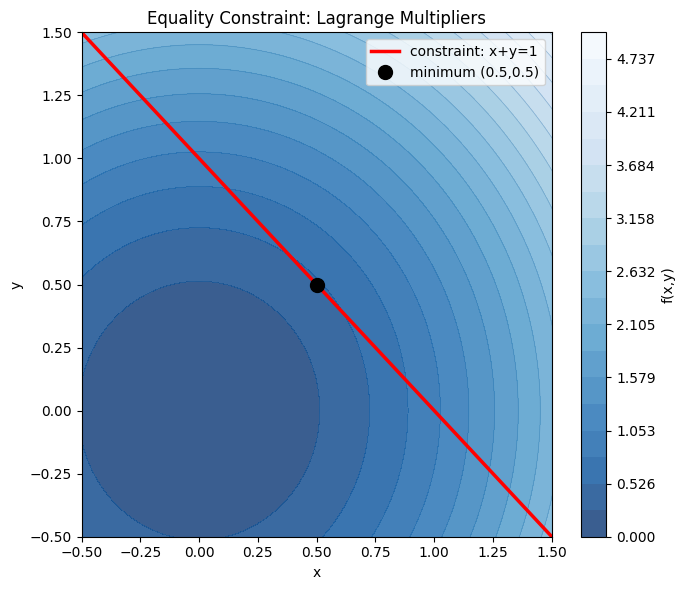

The minimum on the constraint line is where the circular level curve is tangent to the line.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Minimise f(x,y) = x^2 + y^2  subject to  x + y = 1
# Lagrangian: L = x^2 + y^2 - lam*(x + y - 1)
# dL/dx = 2x - lam = 0  =>  x = lam/2
# dL/dy = 2y - lam = 0  =>  y = lam/2
# constraint: x + y = 1  =>  lam = 1  =>  x = y = 0.5

x_opt, y_opt = 0.5, 0.5
f_opt = x_opt**2 + y_opt**2
print(f'Analytical solution: x={x_opt}, y={y_opt}, f={f_opt}')

# Visualise
x = np.linspace(-1, 2, 300)
y = np.linspace(-1, 2, 300)
X, Y = np.meshgrid(x, y)
F = X**2 + Y**2

fig, ax = plt.subplots(figsize=(7, 6))
levels = np.linspace(0, 5, 20)
cs = ax.contourf(X, Y, F, levels=levels, cmap='Blues_r', alpha=0.8)
ax.contour(X, Y, F, levels=levels, colors='steelblue', linewidths=0.5, alpha=0.5)
plt.colorbar(cs, ax=ax, label='f(x,y)')

# Constraint line x + y = 1
x_line = np.linspace(-0.5, 1.5, 200)
y_line = 1 - x_line
ax.plot(x_line, y_line, 'r-', lw=2.5, label='constraint: x+y=1')
ax.plot(x_opt, y_opt, 'ko', ms=10, zorder=5, label=f'minimum ({x_opt},{y_opt})')

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Equality Constraint: Lagrange Multipliers')
ax.legend(); ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
plt.tight_layout()
plt.savefig('ch233_equality.png', dpi=120)
plt.show()
print('The minimum on the constraint line is where the circular level curve is tangent to the line.')

## 2. KKT Conditions for Inequality Constraints

**Problem**: minimise f(x) subject to g(x) ≤ 0.

The Karush-Kuhn-Tucker (KKT) conditions extend Lagrange multipliers:

1. **Stationarity**: ∇f + μ∇g = 0
2. **Primal feasibility**: g(x) ≤ 0
3. **Dual feasibility**: μ ≥ 0
4. **Complementary slackness**: μ·g(x) = 0

Condition 4 means either the constraint is active (g=0) or the multiplier is zero. 
This is the mathematical foundation of **support vectors** in SVMs — most training 
points have μ=0; only the points on the margin boundary matter.

mu = 1.1213 (>0: dual feasibility satisfied)
x = y = 1.4142
Constraint: x^2+y^2 = 4.0000 (active at boundary)


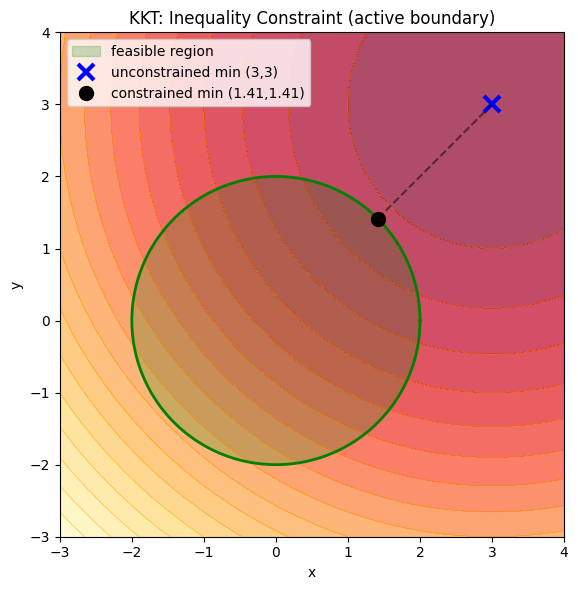

In [3]:
# KKT example: minimise (x-3)^2 + (y-3)^2  subject to  x^2 + y^2 <= 4
# Unconstrained minimum is (3,3) — outside the feasible region (circle r=2)
# So the constrained minimum is on the boundary: x^2 + y^2 = 4

# Lagrangian: L = (x-3)^2 + (y-3)^2 + mu*(x^2 + y^2 - 4)
# Stationarity:
#   2(x-3) + 2*mu*x = 0  =>  x(1+mu) = 3
#   2(y-3) + 2*mu*y = 0  =>  y(1+mu) = 3
# So x = y = 3/(1+mu)
# Constraint active: x^2 + y^2 = 4  =>  2*(3/(1+mu))^2 = 4
# => (1+mu)^2 = 9/2  =>  1+mu = 3/sqrt(2)  =>  mu = 3/sqrt(2) - 1

mu = 3/np.sqrt(2) - 1
x_opt = 3 / (1 + mu)
y_opt = 3 / (1 + mu)
print(f'mu = {mu:.4f} (>0: dual feasibility satisfied)')
print(f'x = y = {x_opt:.4f}')
print(f'Constraint: x^2+y^2 = {x_opt**2 + y_opt**2:.4f} (active at boundary)')

fig, ax = plt.subplots(figsize=(6, 6))
X2, Y2 = np.meshgrid(np.linspace(-3, 4, 300), np.linspace(-3, 4, 300))
F2 = (X2-3)**2 + (Y2-3)**2
ax.contourf(X2, Y2, F2, levels=20, cmap='YlOrRd_r', alpha=0.7)
ax.contour(X2, Y2, F2, levels=20, colors='orange', linewidths=0.5, alpha=0.6)

theta = np.linspace(0, 2*np.pi, 300)
ax.fill(2*np.cos(theta), 2*np.sin(theta), alpha=0.2, color='green', label='feasible region')
ax.plot(2*np.cos(theta), 2*np.sin(theta), 'g-', lw=2)
ax.plot(3, 3, 'bx', ms=12, mew=3, label='unconstrained min (3,3)')
ax.plot(x_opt, y_opt, 'ko', ms=10, zorder=5, label=f'constrained min ({x_opt:.2f},{y_opt:.2f})')
ax.plot([x_opt, 3], [y_opt, 3], 'k--', alpha=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('KKT: Inequality Constraint (active boundary)')
ax.legend(loc='upper left'); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('ch233_kkt.png', dpi=120)
plt.show()

## 3. L2 Regularisation as a Constrained Problem

Ridge regression is normally written as: minimise ||y - Xw||² + λ||w||²

This is **equivalent** to: minimise ||y - Xw||²  subject to  ||w||² ≤ t(λ)

The regularisation parameter λ is the Lagrange multiplier. Larger λ = tighter constraint = 
smaller weights. L1 regularisation (Lasso) uses ||w||₁ ≤ t, whose constraint boundary has 
corners — this is why Lasso produces sparse solutions.

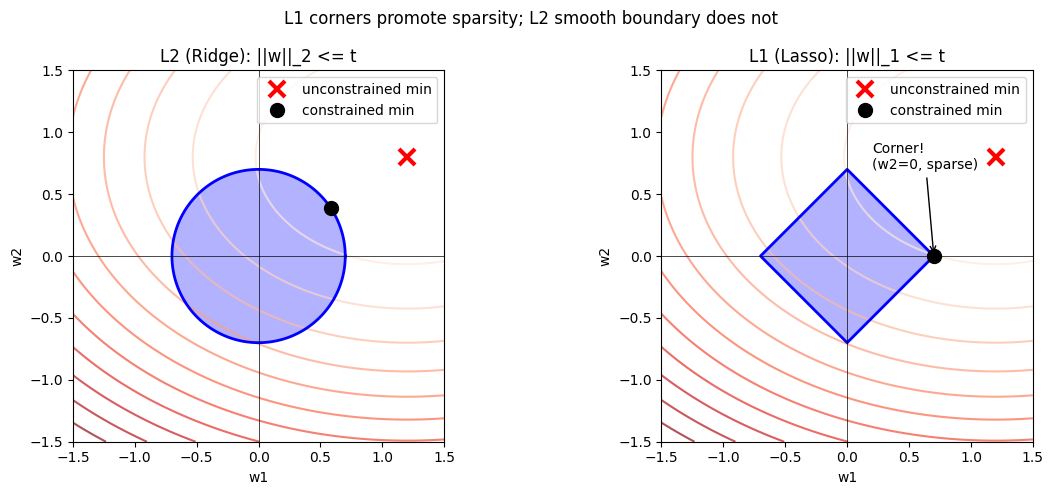

In [4]:
# Visualise L1 vs L2 constraint regions and why L1 promotes sparsity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, norm, title in zip(axes, [2, 1], ['L2 (Ridge): ||w||_2 <= t', 'L1 (Lasso): ||w||_1 <= t']):
    w1 = np.linspace(-1.5, 1.5, 400)
    w2 = np.linspace(-1.5, 1.5, 400)
    W1, W2 = np.meshgrid(w1, w2)

    # Loss landscape (shifted from origin to create interesting intersection)
    w1_star, w2_star = 1.2, 0.8
    Loss = (W1 - w1_star)**2 + 2*(W2 - w2_star)**2
    ax.contour(W1, W2, Loss, levels=15, cmap='Reds', alpha=0.7)

    # Constraint region
    t = 0.7
    if norm == 2:
        theta = np.linspace(0, 2*np.pi, 300)
        cx, cy = t*np.cos(theta), t*np.sin(theta)
        ax.fill(cx, cy, alpha=0.3, color='blue')
        ax.plot(cx, cy, 'b-', lw=2)
        # Minimum is on the circle, not at a corner
        # Approximate: project (w1_star, w2_star) onto circle
        angle = np.arctan2(w2_star, w1_star)
        w_constrained = np.array([t*np.cos(angle), t*np.sin(angle)])
    else:
        # L1 ball is a diamond
        corners = np.array([[t,0],[0,t],[-t,0],[0,-t],[t,0]])
        ax.fill(corners[:,0], corners[:,1], alpha=0.3, color='blue')
        ax.plot(corners[:,0], corners[:,1], 'b-', lw=2)
        # Minimum often hits a corner (sparse solution)
        w_constrained = np.array([t, 0.0])

    ax.plot(w1_star, w2_star, 'rx', ms=12, mew=3, label='unconstrained min')
    ax.plot(w_constrained[0], w_constrained[1], 'ko', ms=10, label='constrained min')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('w1'); ax.set_ylabel('w2')
    ax.set_title(title); ax.legend(); ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)

axes[1].annotate('Corner!\n(w2=0, sparse)', xy=(t, 0), xytext=(0.2, 0.7),
    arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.suptitle('L1 corners promote sparsity; L2 smooth boundary does not', fontsize=12)
plt.tight_layout()
plt.savefig('ch233_regularisation.png', dpi=120)
plt.show()

## 4. Numerical Constrained Optimisation with scipy


In [5]:
from scipy.optimize import minimize

# Portfolio optimisation: minimise variance, target return >= r_min
# weights w, returns mu, covariance Sigma
np.random.seed(42)
n_assets = 5
mu_assets = np.array([0.10, 0.12, 0.08, 0.15, 0.09])  # expected returns
# Random positive-definite covariance
A = np.random.randn(n_assets, n_assets)
Sigma = A.T @ A / n_assets + 0.05 * np.eye(n_assets)

def portfolio_variance(w):
    return w @ Sigma @ w

def portfolio_return(w):
    return mu_assets @ w

r_min = 0.11  # target return

constraints = [
    {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},      # weights sum to 1
    {'type': 'ineq', 'fun': lambda w: portfolio_return(w) - r_min}  # return >= r_min
]
bounds = [(0, 1)] * n_assets  # no short selling

w0 = np.ones(n_assets) / n_assets
result = minimize(portfolio_variance, w0, method='SLSQP',
                  bounds=bounds, constraints=constraints)

print('Optimisation result:', result.message)
print(f'Weights: {result.x.round(4)}')
print(f'Portfolio variance: {result.fun:.6f}')
print(f'Portfolio return:   {portfolio_return(result.x):.4f} (target >= {r_min})')
print(f'Weights sum:        {result.x.sum():.6f}')

Optimisation result: Optimization terminated successfully
Weights: [0.289  0.2533 0.2564 0.2013 0.    ]
Portfolio variance: 0.240347
Portfolio return:   0.1100 (target >= 0.11)
Weights sum:        1.000000


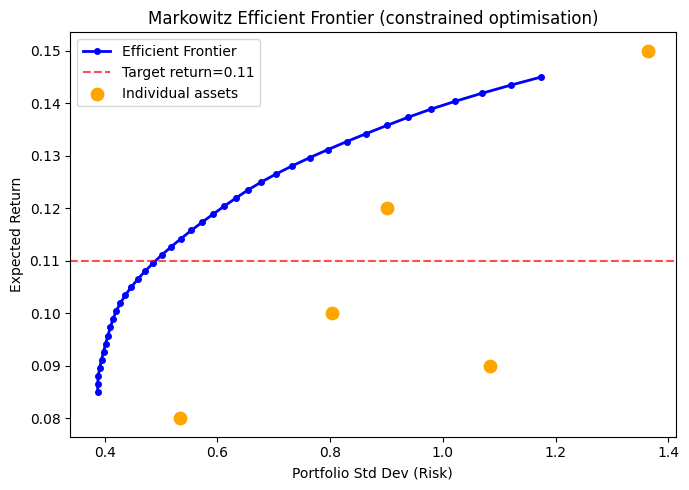

In [6]:
# Efficient frontier: trace the minimum variance for each target return
returns_range = np.linspace(0.085, 0.145, 40)
variances = []

for r_target in returns_range:
    cons = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w, r=r_target: portfolio_return(w) - r}
    ]
    res = minimize(portfolio_variance, w0, method='SLSQP',
                   bounds=bounds, constraints=cons)
    variances.append(res.fun if res.success else np.nan)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(np.sqrt(variances), returns_range, 'b-o', ms=4, lw=2, label='Efficient Frontier')
ax.axhline(r_min, color='red', linestyle='--', alpha=0.7, label=f'Target return={r_min}')
ax.scatter(np.sqrt(np.diag(Sigma)), mu_assets, c='orange', s=80, zorder=5, label='Individual assets')
ax.set_xlabel('Portfolio Std Dev (Risk)')
ax.set_ylabel('Expected Return')
ax.set_title('Markowitz Efficient Frontier (constrained optimisation)')
ax.legend()
plt.tight_layout()
plt.savefig('ch233_frontier.png', dpi=120)
plt.show()

## 5. Summary

| Concept | Key Idea |
|---------|----------|
| Lagrange multipliers | At constrained minimum, ∇f ∥ ∇g |
| KKT conditions | Extend Lagrange to inequality constraints |
| Complementary slackness | μ·g(x)=0: either constraint active or multiplier zero |
| L2 regularisation | Equivalent to weight-norm equality constraint |
| L1 regularisation | Diamond constraint; corners produce sparsity |
| scipy SLSQP | Sequential Least SQuares Programming solver |

## 6. Forward References

- The KKT complementary slackness condition reappears in ch291 — Optimisation Methods, 
where we derive support vector machines formally.
- The efficient frontier construction previews ch271 — Data and Measurement and ch293 — Clustering, 
where risk-return tradeoffs model real portfolio decisions.
- L1 sparsity connects to ch298 — Information Theory: sparse representations minimise redundancy.